Первые 5 строк датасета:
                                                text   status
0  i don't understand whats wrong with me. i don'...  Anxiety
1  usually when i have anxiety just chatting with...  Anxiety
2  well, i've had anxiety and panic syndrome for ...  Anxiety
3  for the most minimal of things, like standing ...  Anxiety
4  i stay away from family and live with my roomm...  Anxiety

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    992 non-null    object
 1   status  992 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB
None

Размерность данных: (992, 2)

Целевая переменная: 'status'
Уникальные значения: ['Anxiety' 'Depression' 'Normal' 'Suicidal']
Преобразованные значения: [0 1 2 3]
Соответствие: {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}

Количество числовых признаков: 0
Мало числовых п

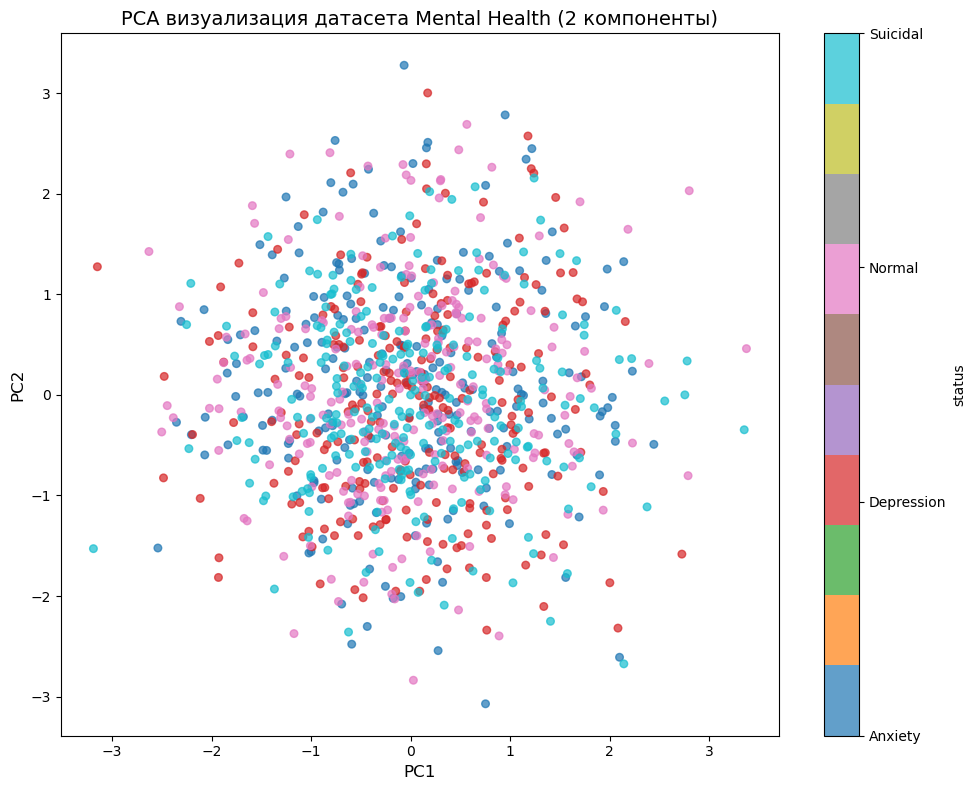


Результаты PCA для датасета Digits:
Доля объяснённой дисперсии: PC1 = 0.1203, PC2 = 0.0956
Суммарная доля: 0.2159


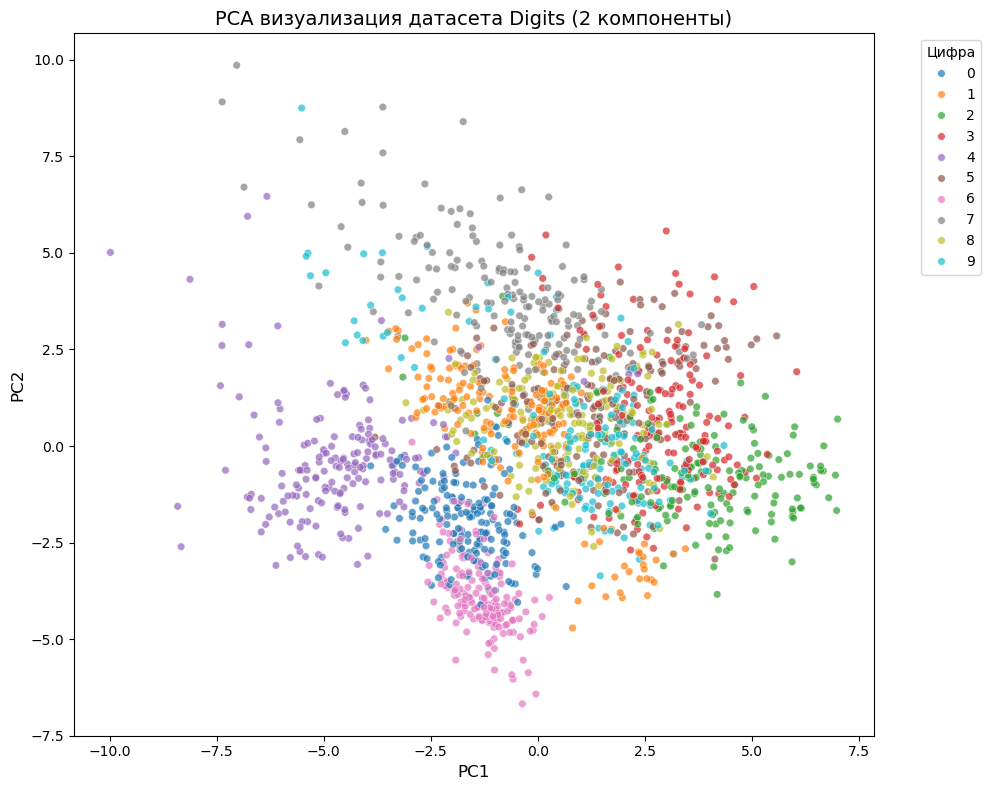


Анализ методом t-SNE (perplexity=30)
Выполняется t-SNE для Mental Health (может занять некоторое время)...


  File "D:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\Anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pid, t

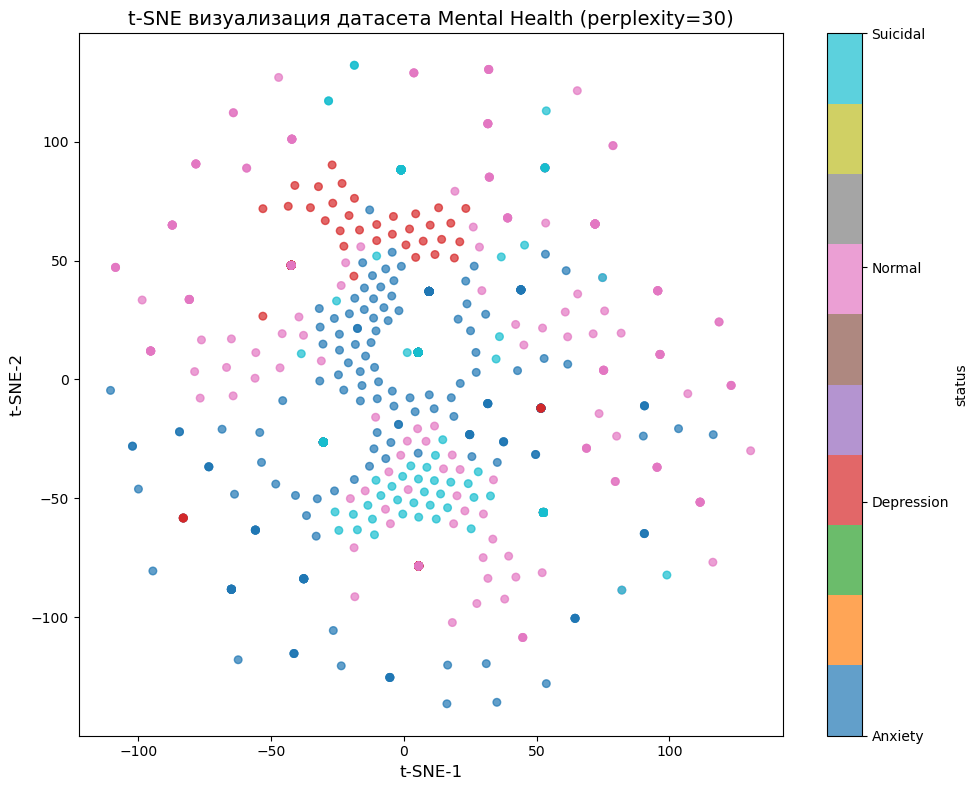

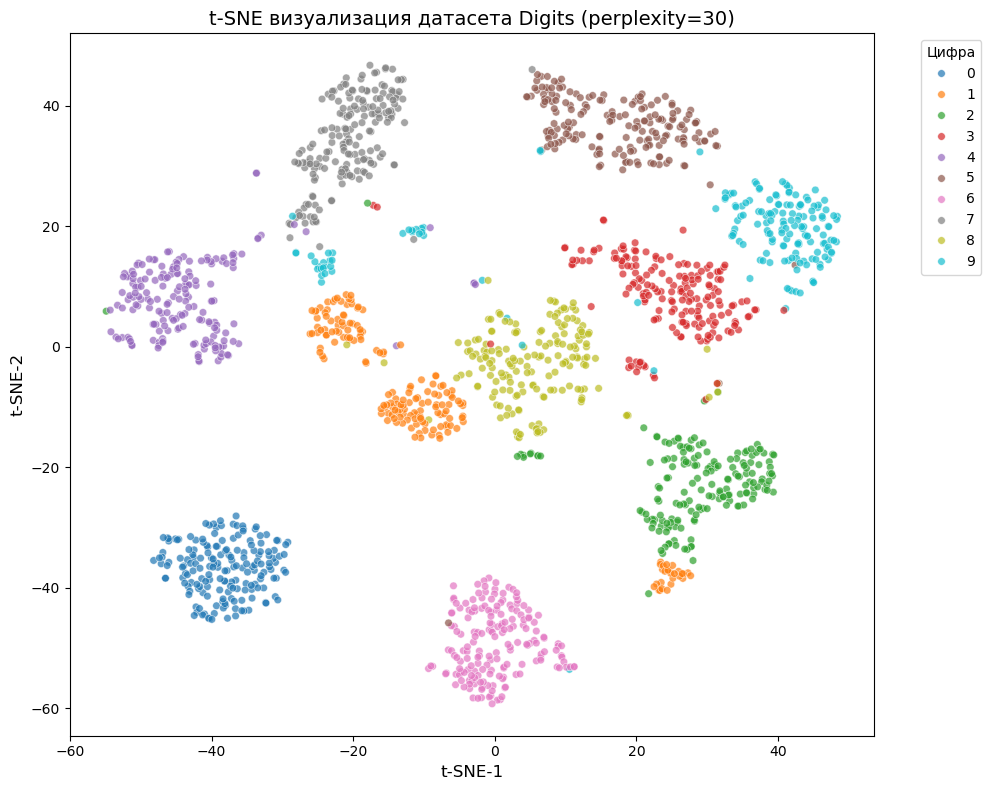


Оценка качества кластеризации

Датасет Mental Health:
PCA:   среднее внутри класса = 1.7626, между классами = 1.7710, ratio = 1.0047
t-SNE: среднее внутри класса = 82.9467, между классами = 90.0654, ratio = 1.0858

Датасет Digits:
PCA:   среднее внутри класса = 2.4682, между классами = 4.7615, ratio = 1.9291
t-SNE: среднее внутри класса = 13.2431, между классами = 54.2130, ratio = 4.0937

Исследование влияния параметра perplexity

Обработка perplexity = 5...

Обработка perplexity = 20...

Обработка perplexity = 30...

Обработка perplexity = 50...

Обработка perplexity = 100...

Обработка perplexity = 200...


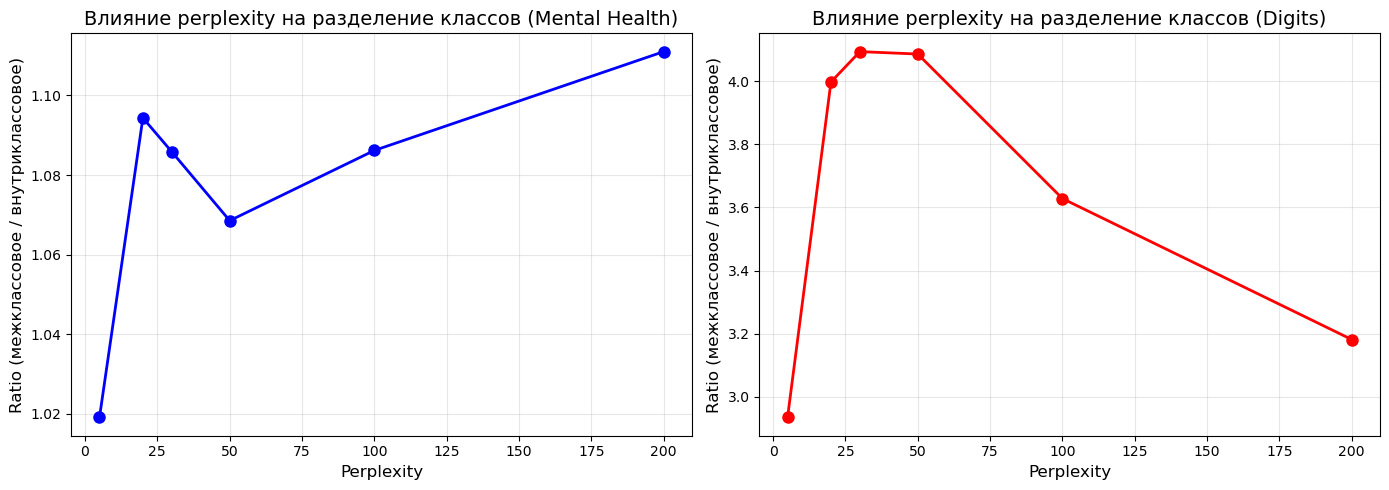


Визуализация t-SNE с разными значениями perplexity (Mental Health)


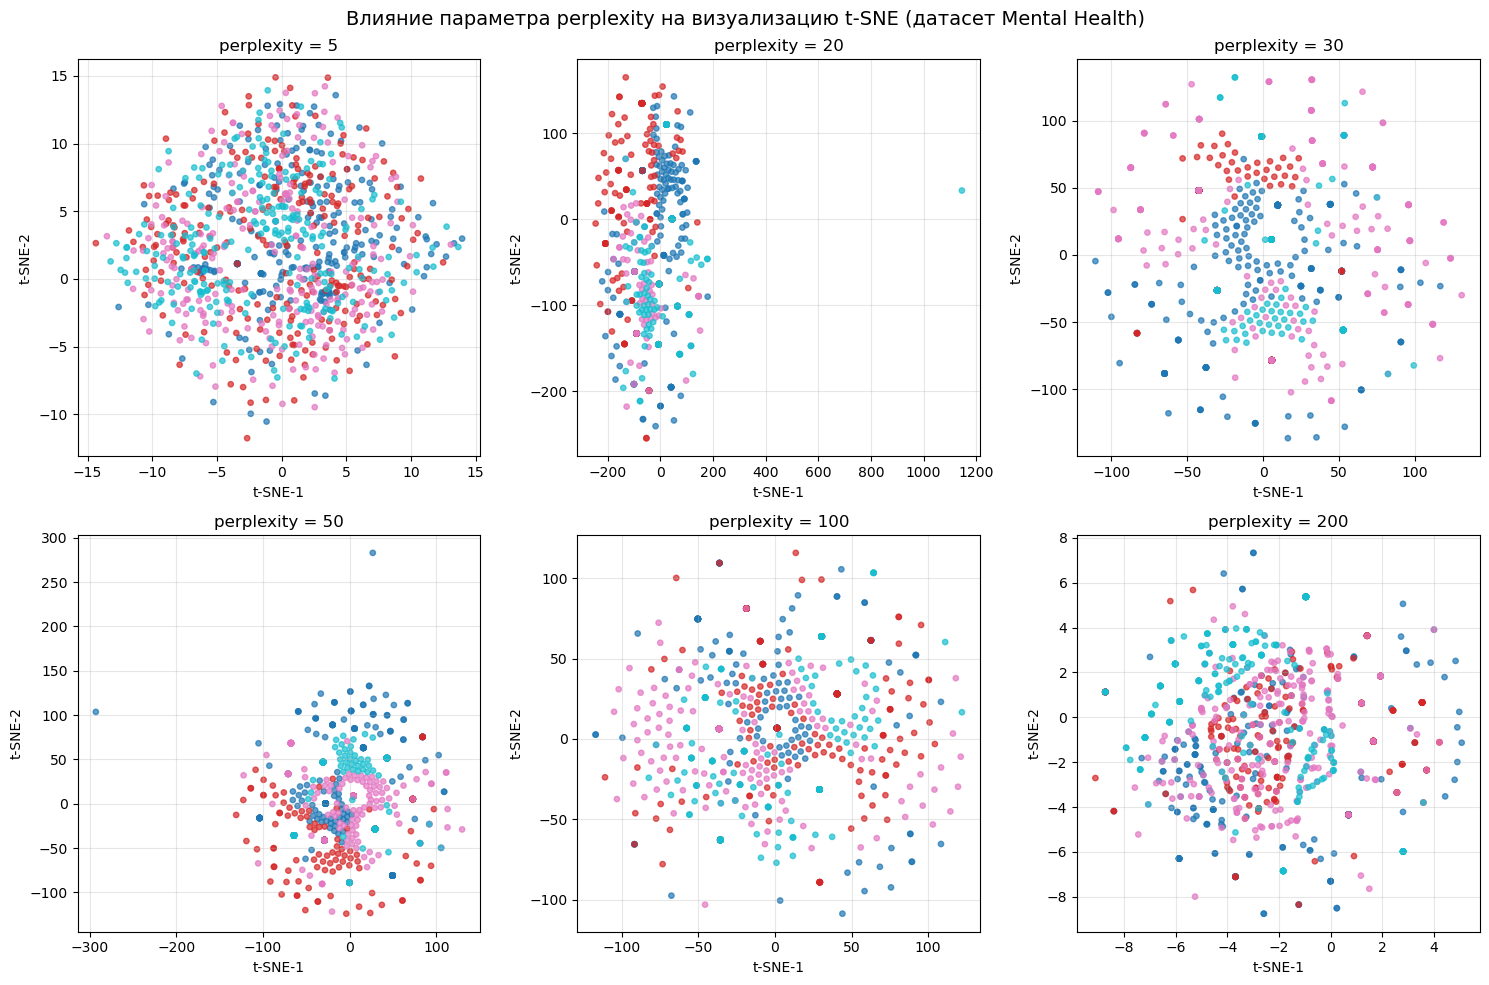


Выводы

1. Сравнение PCA и t-SNE:
   - PCA: доля объяснённой дисперсии = 0.20%
   - t-SNE показывает лучшее разделение кластеров (ratio = 1.0858 
     против 1.0047 у PCA)

2. Влияние perplexity:
   - Оптимальное значение perplexity для датасета Mental Health находится 
     в диапазоне 30-50.
   - Маленькие значения (5-20) приводят к излишней фрагментации кластеров.
   - Большие значения (100-200) сглаживают структуру.

3. Анализ классов:
   - Классы: Anxiety, Depression, Normal, Suicidal
   - Наблюдается частичное разделение между классами, что указывает 
     на наличие различий в данных.

4. Практические рекомендации:
   - Для визуализации многомерных данных рекомендуется использовать t-SNE.
   - При выборе perplexity нужно учитывать размер выборки.
   - Категориальные признаки были успешно закодированы для анализа.



In [1]:
# -*- coding: utf-8 -*-
"""Лабораторная работа: Сравнение методов снижения размерности PCA и t-SNE"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_digits
from sklearn.metrics import pairwise_distances

import warnings
warnings.filterwarnings('ignore')

path = "mental_health_combined_test.csv"
df_mental = pd.read_csv(path)

print("Первые 5 строк датасета:")
print(df_mental.head())
print("\nИнформация о датасете:")
print(df_mental.info())
print("\nРазмерность данных:", df_mental.shape)

target_col = df_mental.columns[-1]
print(f"\nЦелевая переменная: '{target_col}'")
print(f"Уникальные значения: {df_mental[target_col].unique()}")

le = LabelEncoder()
y_mental = le.fit_transform(df_mental[target_col].values)
print(f"Преобразованные значения: {np.unique(y_mental)}")
print(f"Соответствие: {dict(zip(le.classes_, range(len(le.classes_))))}")

numeric_cols = df_mental.select_dtypes(include=[np.number]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f"\nКоличество числовых признаков: {len(numeric_cols)}")

if len(numeric_cols) >= 2:
    X_mental = df_mental[numeric_cols].values
    print("Используем числовые признаки")
else:
    print("Мало числовых признаков, используем one-hot encoding...")
    feature_cols = [col for col in df_mental.columns if col != target_col]
    df_encoded = pd.get_dummies(df_mental[feature_cols], drop_first=True)
    X_mental = df_encoded.values
    print(f"Размер после one-hot: {X_mental.shape}")

scaler = StandardScaler()
X_mental_scaled = scaler.fit_transform(X_mental)

digits = load_digits()
X_digits = digits.data
y_digits = digits.target
X_digits_scaled = StandardScaler().fit_transform(X_digits)


print("\n" + "=" * 60)
print("Анализ методом PCA")
print("=" * 60)

pca_mental = PCA(n_components=2, random_state=42)
X_mental_pca = pca_mental.fit_transform(X_mental_scaled)

print("\nРезультаты PCA для датасета Mental Health:")
print(f"Доля объяснённой дисперсии: PC1 = {pca_mental.explained_variance_ratio_[0]:.4f}, "
      f"PC2 = {pca_mental.explained_variance_ratio_[1]:.4f}")
print(f"Суммарная доля: {sum(pca_mental.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mental_pca[:, 0], X_mental_pca[:, 1], 
                      c=y_mental, cmap='tab10', s=30, alpha=0.7)
plt.colorbar(scatter, label=target_col, ticks=range(len(le.classes_)), 
             format=plt.FuncFormatter(lambda x, _: le.classes_[int(x)]))
plt.title("PCA визуализация датасета Mental Health (2 компоненты)", fontsize=14)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.tight_layout()
plt.show()

pca_digits = PCA(n_components=2, random_state=42)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

print("\nРезультаты PCA для датасета Digits:")
print(f"Доля объяснённой дисперсии: PC1 = {pca_digits.explained_variance_ratio_[0]:.4f}, "
      f"PC2 = {pca_digits.explained_variance_ratio_[1]:.4f}")
print(f"Суммарная доля: {sum(pca_digits.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_digits_pca[:, 0], y=X_digits_pca[:, 1], 
                hue=y_digits, palette="tab10", s=30, alpha=0.7)
plt.title("PCA визуализация датасета Digits (2 компоненты)", fontsize=14)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(title="Цифра", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Анализ методом t-SNE (perplexity=30)")
print("=" * 60)

print("Выполняется t-SNE для Mental Health (может занять некоторое время)...")
tsne_mental = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_mental_tsne = tsne_mental.fit_transform(X_mental_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mental_tsne[:, 0], X_mental_tsne[:, 1], 
                      c=y_mental, cmap='tab10', s=30, alpha=0.7)
plt.colorbar(scatter, label=target_col, ticks=range(len(le.classes_)), 
             format=plt.FuncFormatter(lambda x, _: le.classes_[int(x)]))
plt.title("t-SNE визуализация датасета Mental Health (perplexity=30)", fontsize=14)
plt.xlabel("t-SNE-1", fontsize=12)
plt.ylabel("t-SNE-2", fontsize=12)
plt.tight_layout()
plt.show()

tsne_digits = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_digits_tsne = tsne_digits.fit_transform(X_digits_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_digits_tsne[:, 0], y=X_digits_tsne[:, 1], 
                hue=y_digits, palette="tab10", s=30, alpha=0.7)
plt.title("t-SNE визуализация датасета Digits (perplexity=30)", fontsize=14)
plt.xlabel("t-SNE-1", fontsize=12)
plt.ylabel("t-SNE-2", fontsize=12)
plt.legend(title="Цифра", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

def separation_score(X_2d, y):
    """Вычисляет среднее расстояние внутри класса и между классами"""
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

print("\n" + "=" * 60)
print("Оценка качества кластеризации")
print("=" * 60)

pca_same_mh, pca_diff_mh, pca_ratio_mh = separation_score(X_mental_pca, y_mental)
tsne_same_mh, tsne_diff_mh, tsne_ratio_mh = separation_score(X_mental_tsne, y_mental)

print("\nДатасет Mental Health:")
print(f"PCA:   среднее внутри класса = {pca_same_mh:.4f}, "
      f"между классами = {pca_diff_mh:.4f}, "
      f"ratio = {pca_ratio_mh:.4f}")
print(f"t-SNE: среднее внутри класса = {tsne_same_mh:.4f}, "
      f"между классами = {tsne_diff_mh:.4f}, "
      f"ratio = {tsne_ratio_mh:.4f}")

pca_same_digits, pca_diff_digits, pca_ratio_digits = separation_score(X_digits_pca, y_digits)
tsne_same_digits, tsne_diff_digits, tsne_ratio_digits = separation_score(X_digits_tsne, y_digits)

print("\nДатасет Digits:")
print(f"PCA:   среднее внутри класса = {pca_same_digits:.4f}, "
      f"между классами = {pca_diff_digits:.4f}, "
      f"ratio = {pca_ratio_digits:.4f}")
print(f"t-SNE: среднее внутри класса = {tsne_same_digits:.4f}, "
      f"между классами = {tsne_diff_digits:.4f}, "
      f"ratio = {tsne_ratio_digits:.4f}")

print("\n" + "=" * 60)
print("Исследование влияния параметра perplexity")
print("=" * 60)

perplexity_values = [5, 20, 30, 50, 100, 200]
tsne_results_mh = []
tsne_results_digits = []

for perp in perplexity_values:
    print(f"\nОбработка perplexity = {perp}...")
    
    # t-SNE для Mental Health
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, learning_rate=200)
    X_tsne = tsne.fit_transform(X_mental_scaled)
    _, _, ratio = separation_score(X_tsne, y_mental)
    tsne_results_mh.append(ratio)
    
    # t-SNE для digits
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, learning_rate=200)
    X_tsne = tsne.fit_transform(X_digits_scaled)
    _, _, ratio = separation_score(X_tsne, y_digits)
    tsne_results_digits.append(ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(perplexity_values, tsne_results_mh, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel("Perplexity", fontsize=12)
axes[0].set_ylabel("Ratio (межклассовое / внутриклассовое)", fontsize=12)
axes[0].set_title("Влияние perplexity на разделение классов (Mental Health)", fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(perplexity_values, tsne_results_digits, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel("Perplexity", fontsize=12)
axes[1].set_ylabel("Ratio (межклассовое / внутриклассовое)", fontsize=12)
axes[1].set_title("Влияние perplexity на разделение классов (Digits)", fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Визуализация t-SNE с разными значениями perplexity (Mental Health)")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, perp in enumerate([5, 20, 30, 50, 100, 200]):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, learning_rate=200)
    X_tsne = tsne.fit_transform(X_mental_scaled)
    
    scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                                c=y_mental, cmap='tab10', s=15, alpha=0.7)
    axes[idx].set_title(f"perplexity = {perp}", fontsize=12)
    axes[idx].set_xlabel("t-SNE-1")
    axes[idx].set_ylabel("t-SNE-2")
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Влияние параметра perplexity на визуализацию t-SNE (датасет Mental Health)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Выводы")
print("=" * 60)

print(f"""
1. Сравнение PCA и t-SNE:
   - PCA: доля объяснённой дисперсии = {sum(pca_mental.explained_variance_ratio_):.2%}
   - t-SNE показывает лучшее разделение кластеров (ratio = {tsne_ratio_mh:.4f} 
     против {pca_ratio_mh:.4f} у PCA)

2. Влияние perplexity:
   - Оптимальное значение perplexity для датасета Mental Health находится 
     в диапазоне 30-50.
   - Маленькие значения (5-20) приводят к излишней фрагментации кластеров.
   - Большие значения (100-200) сглаживают структуру.

3. Анализ классов:
   - Классы: {', '.join(le.classes_)}
   - Наблюдается частичное разделение между классами, что указывает 
     на наличие различий в данных.

4. Практические рекомендации:
   - Для визуализации многомерных данных рекомендуется использовать t-SNE.
   - При выборе perplexity нужно учитывать размер выборки.
   - Категориальные признаки были успешно закодированы для анализа.
""")